# Validação externa e mapa dos perfis

Este notebook verifica se os perfis encontrados na clusterização dizem algo
sobre os municípios que não foi usado para formá-los, e mostra onde cada
perfil se localiza no estado. Responde à parte de caracterização da pergunta
(iii) do artigo.

Saídas:

- **Figura 6** do artigo (`figura6_mapa_perfis`): o mapa dos perfis;
- `data/processed/tabela_kruskal.csv`: o teste de Kruskal–Wallis e o tamanho
  de efeito ε² da variável de validação externa e das 22 features;
- figura de apoio: `figura_via_publica_perfis`.

**Critério definido antes da execução.** A validação externa é feita apenas
com `prop_via_publica` (proporção de ocorrências em via pública), que não
entrou na modelagem. O mesmo teste aplicado às 22 features é descritivo e
circular, uma vez que foram essas variáveis que formaram os perfis.

A seção 0 confere a malha municipal do IBGE e não depende do modelo
escolhido. As seções 1 a 4 dependem do `perfis.csv`, gerado pelo notebook 05
depois da escolha do modelo pelo grupo.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# Os notebooks ficam em notebooks/ e o código do projeto em src/. Estas duas
# linhas apontam o Python para src/, para os "from config import ..." abaixo
# funcionarem tanto rodando daqui quanto da raiz do projeto.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

from config import BASE_FINAL_CSV
from estilo import aplicar_estilo
from figuras import plot_mapa_categorias
from malha import carregar_malha_sp

aplicar_estilo()   # mesma fonte, cores e grade em todas as figuras do artigo
# Se algum import acima falhar, quase sempre é o editor apontando para outra
# instalação do Python. O caminho impresso aqui é o que precisa ter as
# bibliotecas do requirements.txt.
print("Python:", sys.executable)

# O código do IBGE é identificador, não quantidade: lido como texto para não
# virar número em nenhuma etapa.
base = pd.read_csv(BASE_FINAL_CSV, dtype={"codigo_ibge": str})

Python: D:\RP 2\database-rp2\.venv\Scripts\python.exe


## 0. Conferência da malha municipal

A malha municipal é o desenho do contorno de cada município, publicado pelo
IBGE. Ela é obtida da API de malhas do IBGE na primeira execução e guardada
em `data/raw/ibge/malha_sp_municipios.geojson`; nas execuções seguintes, é
lida do disco. A junção com a base é feita pelo código IBGE, como em todo o
projeto.

In [2]:
malha = carregar_malha_sp()

# Todo município da base precisa ter um contorno na malha; senão ele some do
# mapa sem nenhum aviso.
faltando = set(base["codigo_ibge"]) - set(malha["codigo_ibge"])
assert not faltando, f"municípios da base sem polígono na malha: {faltando}"
print(f"{len(malha)} polígonos na malha | {base['codigo_ibge'].nunique()} "
      "municípios da base, todos encontrados")

645 polígonos na malha | 645 municípios da base, todos encontrados


O mapa abaixo serve apenas para conferir a junção e não é salvo. A taxa
de urbanização é dividida em quatro faixas com o mesmo número de municípios
(quartis), e cada faixa recebe um tom de azul. Uma junção errada produziria
municípios em branco ou um padrão espacial sem relação com o conhecido.

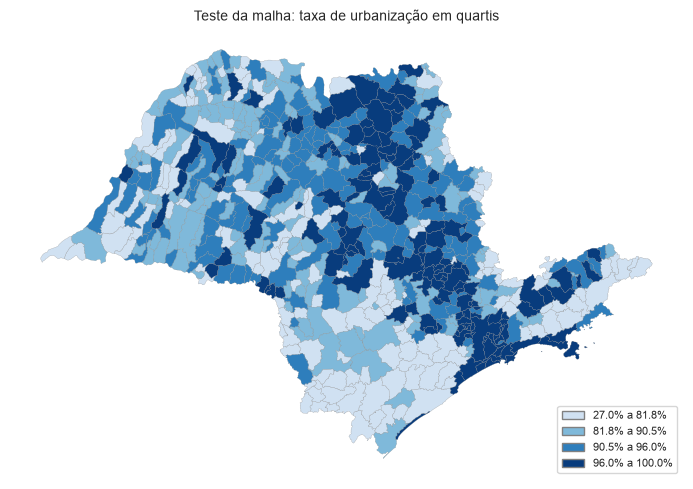

In [3]:
# pd.qcut divide em faixas com o mesmo número de municípios em cada uma;
# retbins=True devolve também os limites, que usamos na legenda.
faixa, limites = pd.qcut(base["taxa_urbanizacao"], 4, labels=False,
                         retbins=True)
teste = malha.merge(base[["codigo_ibge"]].assign(faixa=faixa + 1),
                    on="codigo_ibge", how="left")
rotulos = {i + 1: f"{limites[i]:.1f}% a {limites[i + 1]:.1f}%"
           for i in range(4)}
fig = plot_mapa_categorias(teste, "faixa", rotulos,
                           "Teste da malha: taxa de urbanização em quartis")